Скачиваем библиотеки

In [1]:
import pandas as pd
import numpy as np

import statistics
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import t

#### Проект
Наша кампания ранне имела всего один продукт, он был запущен давно. У нас есть записи сколько выручки нам приносил этот продукт за каждый день его работы. Пару месяцев назад кампания запустила второй продукт, и так же ежедневно фиксировала выручку которую он нам приносил. Данные по выручкам сохранены ниже в переменных product1 и product2.<br>
Наша задача сделать полный анализ на основе всего лишь этих двух списках.

In [6]:
### для загрузки данных
with open('project.txt', 'r') as fp:
    for i, line in enumerate(fp):
        if i == 0:
            product1 = [int(i) for i in line.split(' ')]
        if i == 1:
            product2 = [int(i) for i in line.split(' ')]

fp.close()

**Задача 1**<br>
подсчитайте среднее арифметическое (mean), медиану и моду для обоих списков: product1 и product2

In [14]:
mean_product1=np.mean(product1)
print("Среднее арифметическое product1:", mean_product1)
mean_product2=np.mean(product2)
print("Среднее арифметическое product2:", mean_product2)

Среднее арифметическое product1: 199.103
Среднее арифметическое product2: 193.5


In [15]:
median_product1=np.median(product1)
print("Медиана product1:", median_product1)
median_product2=np.median(product2)
print("Медиана product2:", median_product2)

Медиана product1: 198.5
Медиана product2: 194.5


In [17]:
moda_product1=statistics.mode(product1)
print("Мода product1:", moda_product1)
moda_product2=statistics.mode(product2)
print("Мода product2:", moda_product2)

Мода product1: 186
Мода product2: 227


Какая из трех метрик будет наименее показательной, и почему?<br>
На основе оставшихся двух метрик какой продукт в среднем приносит больше выручки?

Наименее показательная метрика это мода. Потому что мода показывает лишь самое частое значение. В данных по выручке им может оказаться случайный мелкий чек, который не отражает реальный средний уровень доходов.
На основе двух оставшихся метрик (среднего и медианы) product1 приносит в среднем больше выручки, так как оба его показателя выше, чем у product2

**Задача 2**<br>
подсчитайте стандартное отклонение и скажите оценка какого продукта является более точной?

In [20]:
print(f'стандартное отклонение product1:{np.std(product1)}')
print(f'стандартное отклонение product2:{np.std(product2)}')

стандартное отклонение product1:28.793964489107783
стандартное отклонение product2:29.589018233121557


У product1: 28.79 оценка является более точной, так как чем меньше отклонение, тем меньше разброс данных вокруг среднего.

**Задача 3**<br>
Нарисуйте распределение вероятности выручки для продукта1 и для продукта2.<br>
Можете использовать гистограмму или kdeplot

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

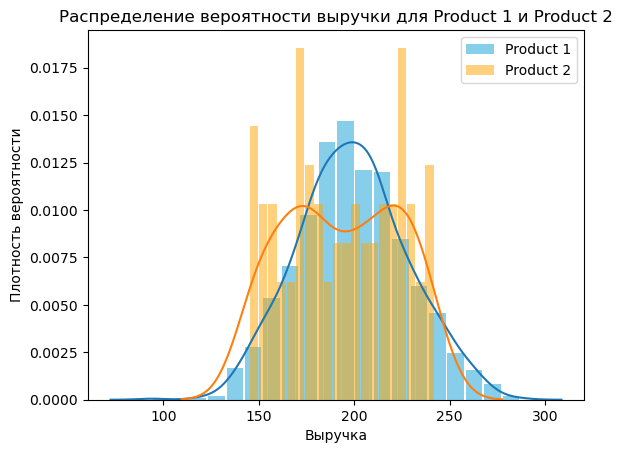

In [25]:
sns.kdeplot(product1)
plt.hist(product1, rwidth=0.9, bins=20, color='skyblue', label='Product 1', density=True )
sns.kdeplot(product2)
plt.hist(product2, rwidth=0.9, bins=20, color='orange', label='Product 2', density=True, alpha=0.5)
plt.title('Распределение вероятности выручки для Product 1 и Product 2')
plt.xlabel('Выручка')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.show()

**Задача 4**<br>
Посчитайте размах выручки для продукта1 и для продукта2<br>
Сходится ли разница в размахах и разница в стандартных отклонениях, какая может быть причина?

In [28]:
min_revenue1=min(product1)
min_revenue2=min(product2)

max_revenue1=max(product1)
max_revenue2=max(product2)

print(f'размах выручки для продукта1: {max_revenue1-min_revenue1}')
print(f'размах выручки для продукта2: {max_revenue2-min_revenue2}')

размах выручки для продукта1: 193
размах выручки для продукта2: 97


Нет, они не сходятся. Размах зависит только от двух крайних точек (Max - Min). У product1 появился аномальный выброс (очень крупный или мелкий чек), который сильно увеличил размах (193 против 97).Стандартное отклонение считает средний разброс всех точек. Почти одинаковые значения (~28.8 и ~29.6) показывают, что основная масса покупок у обоих продуктов распределена с одинаковой плотностью.

**Задача 5**<br>
Посчитайте межквартильный разммах IQR для продукта1 и продукта2<br>
Теперь убрав выбросы что мы можем сказать о разбросе данных?

In [30]:
IQR1=np.percentile(product1,75)-np.percentile(product1,25)
IQR2=np.percentile(product2,75)-np.percentile(product2,25)
print(f'межквартильный разммах IQR для продукта1: {IQR1}')
print(f'межквартильный разммах IQR для продукта2: {IQR2}')

межквартильный разммах IQR для продукта1: 38.25
межквартильный разммах IQR для продукта2: 51.0


У product2 типичный разброс выручки больше, данные product1 более кучные и стабильные. Ранее высокий размах у него был только из-за единичных выбросов. Без них видно, что основной поток продаж product1 предсказуемее.

**Задача 6**<br>
Нарисуйте box-plot для продукта1 и с рисунка скажите при каких значениях начинаются выбросы

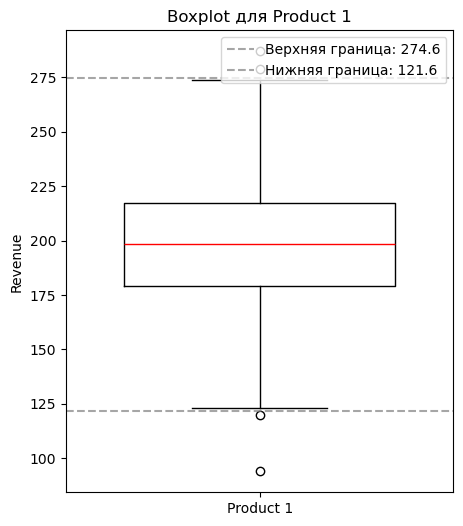

In [39]:
data = np.array(product1)

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

plt.figure(figsize=(5,6))
plt.boxplot(product1, widths=0.7, patch_artist=False, medianprops={'color': 'red'})
plt.axhline(upper_bound, color='gray', linestyle='--', alpha=0.7, label=f'Верхняя граница: {upper_bound:.1f}')
plt.axhline(lower_bound, color='gray', linestyle='--', alpha=0.7, label=f'Нижняя граница: {lower_bound:.1f}')

plt.title('Boxplot для Product 1')
plt.ylabel('Revenue')
plt.xticks([1], ['Product 1'])
plt.legend(loc='upper right')

plt.show()


In [ ]:
Верхние выбросы начинаются при значениях выше 274.5
Нижние выбросы начинаются при значениях ниже 121

**Задача 7**<br>
Нарисуйте QQ plot выручки для обоих продуктов<br>
Какое из распределений является нормальным?

In [ ]:
Нормальным является распределение продукта 1, синие точки почти полностью и ровно ложатся на красную прямую линию.

Каких значений много или наоборот не достает в продукте2 чтобы значения стали нормально распределенными?

Сверху (справа): точки уходят ниже красной линии — в данных не хватает высоких значений (выручки выше ~240).
Снизу (слева): точки идут горизонтально выше красной линии — в данных не хватает низких значений (выручки ниже ~140). 
Слишком много значений сгруппировано вокруг среднего значения (в районе 180–220),из-за чего распределение получается слишком «сжатым» по сравнению с нормальным.

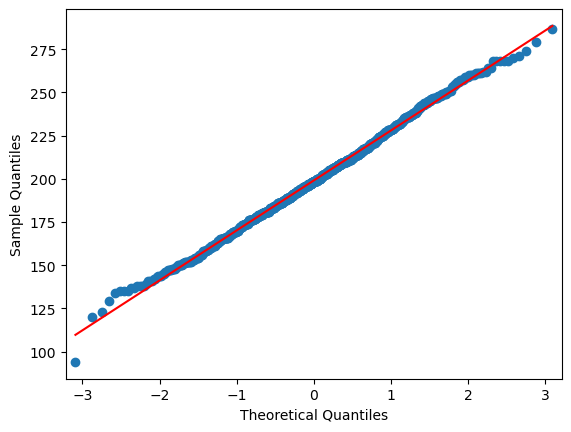

In [40]:
sm.qqplot(np.array(product1),line='r')
plt.show()

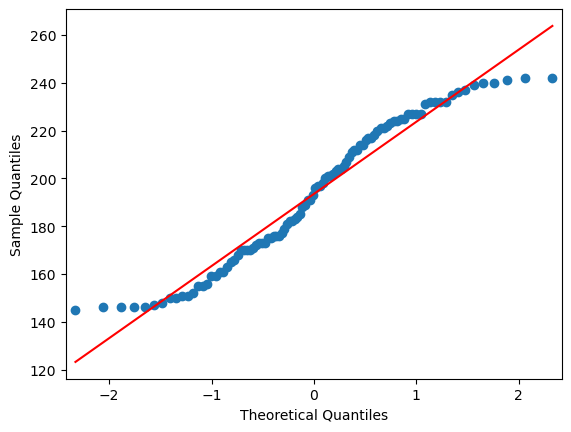

In [41]:
sm.qqplot(np.array(product2),line='r')
plt.show()

**Задача 8**<br>
И так мы знаем что выручка продукта1 является нормально распредленной, переведите все значения в стандартное нормальное распределение используя текущие mean и std<br>
создайте новую переменнуя и запишите новые значения туда

In [53]:
product1_std=(product1 - np.mean(product1)) / np.std(product1)
product2_std=(product2 - np.mean(product2)) / np.std(product2)

Нарисуйте kdeplot нового стандартного распределения

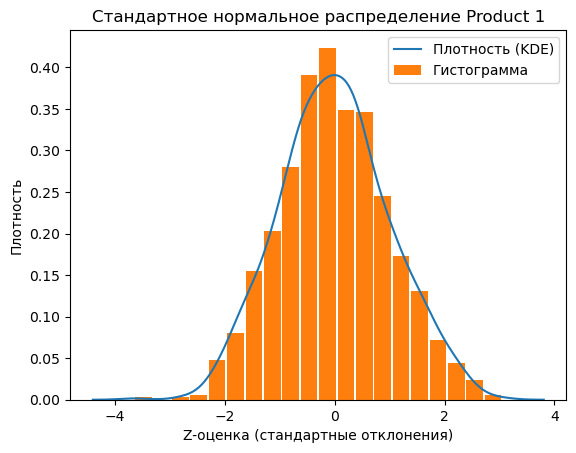

In [54]:
sns.kdeplot(product1_std, label='Плотность (KDE)')
plt.hist(product1_std, rwidth=0.9, bins=20,density=True, label='Гистограмма')
plt.title('Стандартное нормальное распределение Product 1')
plt.xlabel('Z-оценка (стандартные отклонения)')
plt.ylabel('Плотность')
plt.legend()
plt.show()

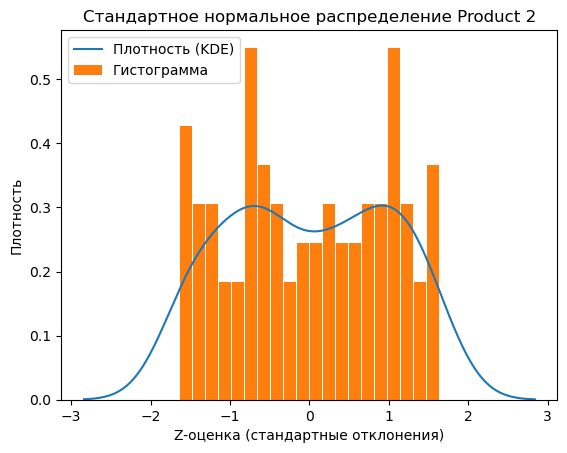

In [56]:
sns.kdeplot(product2_std, label='Плотность (KDE)')
plt.hist(product2_std, rwidth=0.9, bins=20,density=True, label='Гистограмма')
plt.title('Стандартное нормальное распределение Product 2')
plt.xlabel('Z-оценка (стандартные отклонения)')
plt.ylabel('Плотность')
plt.legend()
plt.show()

**Задача 9**<br>
Подсчитайте точку слева от которой будет 1% всей вероятности распределения

In [66]:
left_point1 = norm.ppf(0.01, loc=np.mean(product1), scale=np.std(product1))
left_point2 = norm.ppf(0.01, loc=np.mean(product2), scale=np.std(product2))

print("Точка 1% для product1:", left_point1)
print("Точка 1% для product2:", left_point2)

Точка 1% для product1: 132.11822192555667
Точка 1% для product2: 124.665650338422


Первое значение в списке product1 равно 94. Когда мы преобразуем список в стандартное нормальное распределение, 94 преобразуется в -3.65<br>
Что нам говорит это число, особенно при сравнении с точкой которую мы только что подсчитали?

Значение Z-оценки -3.65 показывает, что выручка 94 находится на 3.65 стандартных отклонения ниже среднего значения. Найденная граница 1% вероятности равна 132.12. Значение 94 (-3.65) находится значительно левее этой границы. Это говорит о том, что значение 94 — экстремально редкое событие. Вероятность получить такую низкую выручку при данном нормальном распределении существенно меньше 1%.

**Задача 10**<br>
Продукт2 новый, но уже достаточно стабилизирвался за эти месяцы. Мы хотим знать сколько он будет в среднем нам приносить ежедневно выручки и в будущем.<br>
Дайте точечную оценку средней выручке продукта2

In [67]:
mean_product2 = np.mean(product2)
print("Точечная оценка средней выручки product2:", mean_product2)

Точечная оценка средней выручки product2: 193.5


Подсчитайте 95% доверительный интервал

In [74]:
mean = np.mean(product2)
std = np.std(product2)
n = len(product2)
ll = norm.ppf(0.025, loc=mean, scale=std / np.sqrt(n))
ul = norm.ppf(0.975, loc=mean, scale=std / np.sqrt(n))

print("95% доверительный интервал:", (ll, ul))

95% доверительный интервал: (np.float64(187.70065899251827), np.float64(199.29934100748173))


**Задача11**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 выше чем 197.5

In [81]:
mean_p1 = np.mean(product1)
std_p1 = np.std(product1, ddof=1)
n1 = len(product1)

In [83]:
dof_11 = len(product1) - 1

In [82]:
t_stat11 = (mean_p1 - 197.5) / (std_p1 / np.sqrt(n1))

In [84]:
p_value11 = 1 - t.cdf(t_stat11, df=dof_11)

In [87]:
p_value11

np.float64(0.03939055962434501)

In [86]:
if p_value11 < 0.05:
    print("Отвергаем H0: средние выручки продуктов статистически значимо различаются")
else:
    print("Не отвергаем H0: средние выручки продуктов равны")

Отвергаем H0: средние выручки продуктов статистически значимо различаются


Какой это был типа АБ теста?

Одновыборочный односторонний t-тест

**Задача12**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 и у продукта2 равны

In [92]:
mean_product1 = np.mean(product1)
mean_product2 = np.mean(product2)

std1 = np.std(product1, ddof=1)
std2 = np.std(product2, ddof=1)

product1_size = len(product1)
product2_size = len(product2)

In [93]:
diff_mean = mean_product1 - mean_product2
err_diff = np.sqrt((std1**2 / product1_size) + (std2**2 / product2_size))

In [94]:
t_stat = diff_mean / err_diff

In [96]:
dof = product1_size + product2_size - 2
p_value = 2 * (1 - t.cdf(abs(t_stat), df=dof))

In [99]:
print("t-статистика:", t_stat)
print("p-value:", p_value)

t-статистика: 1.8014812850572308
p-value: 0.07190130082161539


In [101]:
if p_value < 0.05:
    print("Отвергаем H0: средняя выручка у продукта 1 и продукта 2 статистически значимо различается")
else:
    print("Не отвергаем H0: средняя выручка у продукта 1 и продукта 2 равны")

Не отвергаем H0: средняя выручка у продукта 1 и продукта 2 равны
